# Fine-tuning di un modello di linguaggio neurale (Neural Language Model).

In questo notebook viene svolto il quarto punto del progetto: Fine-tuning di BERT per tre epoche e valutato al termine della terza epoca

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report

In [20]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [21]:
#!pip install transformers

In [22]:
df_train = pd.read_csv("df_train.csv")
df_val = pd.read_csv("df_val.csv")
df_test = pd.read_csv("df_test.csv")

In [23]:
tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-italian-cased")

Per il fine-tuning di BERT è stata definita una classe figlia della classe dataset di PyTorch. Serve a trasformare il dataframe del progetto in un formato leggibile dal modello.

In [ ]:
class ItalianTextDataset(Dataset):

    # Classe figlia della classe Dataset di pytorch

    def __init__(self, df, tokenizer, max_length=512):
        self.texts = df["text"].tolist() # salva testi come liste python
        self.labels = df["label"].tolist() # idem con le labels
        self.tokenizer = tokenizer 
        self.max_length = max_length 

    def __len__(self):
        return len(self.texts) # totale di documenti nel dataset

    def __getitem__(self, idx): # recupera il testo corrispondente all'indice richiessto
        encoding = self.tokenizer( # tokenizzazione
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [25]:
train_dataset = ItalianTextDataset(df_train, tokenizer)
val_dataset = ItalianTextDataset(df_val, tokenizer)
test_dataset = ItalianTextDataset(df_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [26]:
model = AutoModelForSequenceClassification.from_pretrained(
    "dbmdz/bert-base-italian-cased",
    num_labels=2
)
model = model.to("cuda")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-italian-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training

In [27]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
# Cella 6 - Training loop 
train_losses = []
val_losses = []

for epoch in range(3):
    # Train
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to("cuda")
        attention_mask = batch["attention_mask"].to("cuda")
        labels = batch["labels"].to("cuda")

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Val
    model.eval()
    total_val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to("cuda")
            attention_mask = batch["attention_mask"].to("cuda")
            labels = batch["labels"].to("cuda")

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoca {epoch+1}")
    print(f"Train loss: {avg_train_loss:.4f} | Val loss: {avg_val_loss:.4f}")
    print(classification_report(all_labels, all_preds))

Epoca 1
Train loss: 0.2077 | Val loss: 0.0400
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       500
           1       0.98      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000

Epoca 2
Train loss: 0.0493 | Val loss: 0.0338
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       500
           1       1.00      0.98      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000

Epoca 3
Train loss: 0.0176 | Val loss: 0.0178
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       500
           1       0.99      1.00      1.00       500

    accuracy                           0.99 

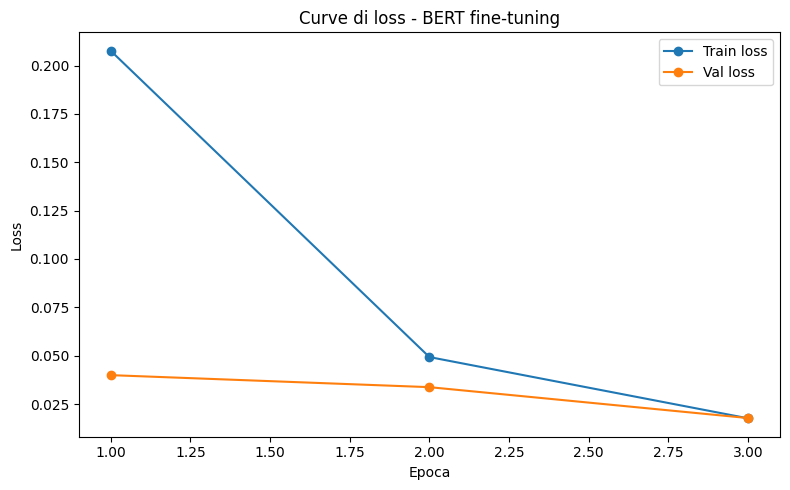

In [29]:
# Cella 7 - Plot curve di loss
plt.figure(figsize=(8, 5))
plt.plot([1, 2, 3], train_losses, label='Train loss', marker='o')
plt.plot([1, 2, 3], val_losses, label='Val loss', marker='o')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Curve di loss - BERT fine-tuning')
plt.legend()
plt.tight_layout()
plt.savefig('bert_loss_curves.png')
plt.show()

### Valutazione di BERT finetunato alla terza epoca su test set

In [30]:
# Cella 8 - Valutazione sul test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to("cuda")
        attention_mask = batch["attention_mask"].to("cuda")
        labels = batch["labels"].to("cuda")

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test set - Epoca 3:")
print(classification_report(all_labels, all_preds))

Test set - Epoca 3:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       500
           1       0.97      0.94      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000

